<a href="https://colab.research.google.com/github/mlemxy/apple-cut-classification/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center>
<h3>Machine Learning for Automated Apple Cut Quality Classification</h3>
</center>

<p style="font-size:12px; float: right; margin: 20px;">INF2008: Machine Learning</p>

# User Manual

This notebook provides a comprehensive guide to building a machine learning system for classifying apple quality using tabular and image data. The project is divided into several sections, each focusing on a specific aspect of the workflow, from data preparation to model deployment.


## Key Features
Tabular Data Analysis: Predicts apple quality based on physical attributes like size, weight, sweetness, and acidity.

Image Data Analysis: Classifies apples as healthy or rotten using Convolutional Neural Networks (CNNs) and transfer learning with ResNet50.

Model Ensembling: Combines predictions from multiple models (XGBoost, Logistic Regression, Random Forest) for improved accuracy.

Deployment: Saves the trained model for real-time predictions on custom data.


## How to Use This Notebook

### Setting Up the Environment
Before running the notebook, ensure all required libraries are installed. If you're using Google Colab, run the following commands in a code cell:
```python
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost tensorflow opencv-python shap
```
For local environments, create a `requirements.txt` file with the following content:
```
pandas
numpy
matplotlib
seaborn
scikit-learn
xgboost
tensorflow
opencv-python
shap
```
Then, install the dependencies using:
```bash
pip install -r requirements.txt
```

### Data Preparation
The `apple_quality.csv` dataset is required for training models based on physical attributes. You may download the file [here](https://www.kaggle.com/datasets/nelgiriyewithana/apple-quality). If you're using Google Colab, upload the file directly:
```python
from google.colab import files
uploaded = files.upload()
```
The [Fruit and Vegetable Disease Dataset](https://www.kaggle.com/datasets/muhammad0subhan/fruit-and-vegetable-disease-healthy-vs-rotten/data) from Kaggle is required for image-based classification. Download the dataset and upload it to Google Colab or your local environment.
For Google Colab, use the following code to upload the dataset:
```python
from google.colab import files
uploaded = files.upload()
```
Extract the dataset if it's in a zip file:
```python
!unzip -q "fruit-and-vegetable-disease-healthy-vs-rotten.zip"
```

### Running the Code
Execute each cell sequentially. The notebook is designed to be self-explanatory, with detailed comments and markdown explanations.
Ensure the datasets are placed in the correct directories:
- Tabular data: `apple_quality.csv`
- Image data: Extracted files from the uploaded zip.

### Custom Predictions
Use the provided code to make predictions on custom data by modifying the `custom_data` dictionary. Example:
```python
custom_data = {
    "Size": 1.3642,
    "Weight": -1.2966,
    "Sweetness": -0.3847,
    "Crunchiness": -0.5530,
    "Juiciness": 3.0309,
    "Ripeness": -1.3038,
    "Acidity": 0.5020
}
```
Convert the dictionary into a DataFrame and make predictions:
```python
custom_df = pd.DataFrame([custom_data])
prediction = loaded_model.predict(custom_df)
```

### Saving and Loading Models
The final ensemble model is saved as a `.pkl` file for future use. You can load it to make predictions without retraining.
Save the Model:
```python
import pickle
with open("AppleQualityClassifier.pkl", "wb") as file:
    pickle.dump(model, file)
```
Load the Model:
```python
with open("AppleQualityClassifier.pkl", "rb") as file:
    loaded_model = pickle.load(file)
```

## Dataset Sources
Tabular Data: The `apple_quality.csv` dataset is used for training models based on physical attributes. The [Apple Quality](https://www.kaggle.com/datasets/nelgiriyewithana/apple-quality) dataset can also be downloaded from Kaggle.

Image Data: The [Fruit and Vegetable Disease Dataset](https://www.kaggle.com/datasets/muhammad0subhan/fruit-and-vegetable-disease-healthy-vs-rotten/data) from Kaggle is used for image-based classification.


## References
[Fruits and Vegetables: Healthy or Rotten](https://www.kaggle.com/code/subhadipde2000/fruits-and-vegetables-healthy-or-rotten)

[Fruit and Vegetable Disease: Healthy vs Rotten](https://www.kaggle.com/code/osamaabobakr/fruit-and-vegetable-disease-healthy-vs-rotten)


## Future Enhancements
Multi-Modal Integration: Combine tabular and image data for a unified classification system.

Real-Time Deployment: Integrate the model into a web or mobile application for real-time quality assessment.

Dataset Expansion: Include more classes (e.g., different fruit types) and conditions (e.g., varying levels of ripeness).


## Notes for Google Colab Users
Google Colab provides free GPU support, which can significantly speed up training for image-based models. To enable GPU, go to **Runtime > Change runtime type > Hardware accelerator > GPU**.

If you disconnect from Colab, you may need to re-upload datasets and reinstall dependencies. Consider saving your work to Google Drive for persistence.


## Conclusion
This notebook provides a complete pipeline for apple quality classification, from data preparation to model deployment. By following the steps outlined in this user manual, you can successfully run the notebook and make predictions on custom data. For further improvements, refer to the **Future Enhancements** section.

# Library Install
Installation of the necessary libraries for data handling, machine learning, visualization, hyperparameter tuning.


In [ ]:
pip install pandas==2.2.2 numpy==1.26.4 scikit-learn==1.2.2 xgboost==2.0.3 matplotlib==3.7.5 seaborn==0.12.2 shap==0.44.1 scikit-optimize==0.10.2 opencv-python==4.8.1.78 tensorflow==2.15.0

In [ ]:
import os
import json
import pickle
import zipfile
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from google.colab import files

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_curve, auc, precision_score,
    recall_score, cohen_kappa_score
)
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import xgboost as xgb

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Activation, GlobalAveragePooling2D
)
from tensorflow.keras.applications import ResNet50

# Table of Contents

1. **[Introduction](#1-introduction)**
   - [1.1 Background](#11-background)
   - [1.2 Objectives](#12-objectives)

2. **[Data Preparation](#2-data-preparation)**
   - [2.1 Tabular Data](#21-tabular-data)
     - [2.1.1 Preprocessing and Feature Engineering](#211-preprocessing)
     - [2.1.2 Data Visualization](#212-data-visualization)
   - [2.2 Image Data](#22-image-data)
     - [2.2.1 Preprocessing](#221-image-data-preprocessing)

3. **[Model Development](#30-model-development)**
   - [3.1 Tabular Data](#31-tabular-data)
     - [3.1.1 Train-Test Split](#311-train-test-split)
     - [3.1.2 Model Pipeline Setups](#312-model-pipeline-setups)
     - [3.1.3 Train Base Models](#313-train-base-models)
     - [3.1.4 Evaluation](#314-evaluation)
     - [3.1.5 Hyperparameter Tuning](#315-hyperparameter-tuning)
     - [3.1.6 ROC Curve Comparison](#316-roc-curve-comparison)
     - [3.1.7 Model Ensembling](#317-model-ensembling)
     - [3.1.8 Final Comparison](#318-final-comparison)
   - [3.2 Image Data](#32-image-data)
     - [3.2.1 Train-Test Split](#321-train-test-split)
     - [3.2.2 Building CNN Model](#322-building-cnn-model)
     - [3.2.3 Training CNN Model](#323-training-cnn-model)
     - [3.2.5 Transfer Learning with ResNet50](#325-transfer-learning-with-resnet50)

4. **[Saving the Model](#40-saving-model)**
   - [4.1 Ensemble Model](#41-ensemble-model)

5. **[Predicting on Custom Data](#50-predicting-custom-data)**
   - [5.1 Ensemble Model Prediction](#51-ensemble-model-prediction)

6. **[Future Enhancements](#6-future-enhancements)**
   - [6.1 Image Data](#61-image-data)
     - [6.1.1 Preprocessing](#611-preprocessing)
     - [6.1.2 Train-Test Split](#612-train-test-split)
     - [6.1.3 Building CNN Model](#613-building-cnn-model)
     - [6.1.4 Training CNN Model](#614-training-cnn-model)
     - [6.1.5 Transfer Learning with ResNet50](#615-transfer-learning-with-resnet50)

### 1. Introduction

#### 1.1 Background

Ensuring the quality of apples is an essential part of the agricultural and food supply chain. This process guarantees that consumers receive only the best produce while helping farmers and distributors maintain high standards. Traditionally, apple quality is assessed through physical traits such as size, weight, sweetness, crunchiness, juiciness, ripeness, and acidity. While these measurements provide valuable information, they may not always detect external blemishes or hidden defects that affect overall quality.

With the rise of machine learning and image recognition technologies, we now have the opportunity to go beyond traditional quality checks. By using both structured data (like measurements) and unstructured data (like images), we can build a more advanced and reliable system for classifying apple quality. This approach, known as a multi-modal system, enhances the accuracy of classification and picks up on details that might otherwise be overlooked.

In this project, we begin by building a predictive model using structured tabular data based on the physical attributes of apples. At the same time, we explore how image-based models can eventually be incorporated to strengthen the overall system. The final goal is to develop an accurate and scalable apple classification system that benefits stakeholders across the supply chain—from farmers and suppliers to everyday consumers.

#### 1.2 Objectives

This project is carried out with the following goals:

**Developing a Classification Model Using Tabular Data**
- Use machine learning algorithms such as XGBoost, Logistic Regression, and Random Forest to predict apple quality based on physical features.
- Perform data preprocessing and feature engineering to prepare the dataset for accurate predictions.
- Apply hyperparameter tuning to improve the performance of each model.
- Evaluate each model’s effectiveness using common metrics such as accuracy, F1 score, and ROC-AUC.

**Exploring Image-Based Classification**
- Train a Convolutional Neural Network (CNN) to classify apple images as either healthy or rotten.
- Experiment with transfer learning by using pre-trained models like ResNet50 to reduce training time and enhance accuracy.
- Compare the results of image-based predictions with those from tabular models.

**Combining Tabular and Image-Based Predictions**
- Investigate the integration of both data types into a single, unified model.
- Study how combining different types of data can improve robustness and real-world applicability.

**Deployment and Real-World Testing**
- Save the trained models so they can be reused for future predictions.
- Provide an interface for testing the model on custom apple data.
- Allow real-time prediction and quality assessment for practical use cases.

By achieving these objectives, this project hopes to demonstrate how modern machine learning methods can contribute meaningfully to agriculture, offering a smarter and more efficient approach to fruit quality assessment.

## 2. Data Preparation

### 2.1 Tabular Data

In [ ]:
df = pd.read_csv("apple_quality.csv")

### Dataset Overview

The dataset used for this project, `apple_quality.csv`, contains structured data representing key physical characteristics of apples. These features serve as the foundation for training the machine learning model to predict quality labels.

The main attributes include:  
- **Size** – general dimensions of the apple  
- **Weight** – how heavy each apple is  
- **Sweetness** – a numeric value reflecting sugar levels  
- **Crunchiness** – texture when bitten into  
- **Juiciness** – how much liquid content is present  
- **Ripeness** – how mature the apple is  
- **Acidity** – degree of tartness  

These variables are typically used in real-world agricultural grading systems and were selected because they can influence both internal quality and consumer perception. Together, they provide a strong foundation for predictive modelling.

By using these features as model inputs, we aim to classify apples into good or bad quality with better consistency and scalability than manual inspection alone. This also sets the stage for future integration with image-based models, enabling a more complete assessment that combines both physical and visual indicators.

In [ ]:
df.head()

,A_id,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
0,0.0,-3.970049,-2.512336,5.346330,-1.012009,1.844900,0.329840,-0.491590483,good
1,1.0,-1.195217,-2.839257,3.664059,1.588232,0.853286,0.867530,-0.722809367,good
2,2.0,-0.292024,-1.351282,-1.738429,-0.342616,2.838636,-0.038033,2.621636473,bad
3,3.0,-0.657196,-2.271627,1.324874,-0.097875,3.637970,-3.413761,0.790723217,good
4,4.0,1.364217,-1.296612,-0.384658,-0.553006,3.030874,-1.303849,0.501984036,good


#### <a id="211-preprocessing"></a> 2.1.1 Preprocessing and Feature Engineering

To prepare the dataset for training, several preprocessing steps were applied to improve model reliability and ensure data consistency.

- Missing values were imputed to prevent data gaps from affecting the outcome  
- Numerical features were standardized to ensure equal weighting during training  
- Categorical data was encoded to allow for proper model interpretation  
- The target label `Quality` was mapped to binary values (good → 1, bad → 0)  
- Non-contributive fields like ID were dropped to reduce noise and improve learning focus  

These steps help create a cleaner dataset that supports better generalization and prepares the model for evaluation with minimal bias or distortion.

In [ ]:
# Map Quality to numeric labels.
df["Quality_numeric"] = df["Quality"].map({"good": 1, "bad": 0})
df = df.dropna(subset=["Quality_numeric"])

In [ ]:
# If extra non-numeric columns exist (e.g., 'Created_by_Nidula_Elgiriyewithana'), drop them.
drop_cols = ["A_id", "Quality"]
for col in df.columns:
    if isinstance(col, str) and "Created_by" in col:
        drop_cols.append(col)

In [ ]:
# Define features and target.
X = df.drop(columns=drop_cols + ["Quality_numeric"], errors='ignore')
y = df["Quality_numeric"]


In [ ]:
X.head()

,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity
0,-3.970049,-2.512336,5.346330,-1.012009,1.844900,0.329840,-0.491590483
1,-1.195217,-2.839257,3.664059,1.588232,0.853286,0.867530,-0.722809367
2,-0.292024,-1.351282,-1.738429,-0.342616,2.838636,-0.038033,2.621636473
3,-0.657196,-2.271627,1.324874,-0.097875,3.637970,-3.413761,0.790723217
4,1.364217,-1.296612,-0.384658,-0.553006,3.030874,-1.303849,0.501984036


In [ ]:
y.head()

,Quality_numeric
0,1.0
1,1.0
2,0.0
3,1.0
4,1.0


#### <a id="212-data-visualization"></a> 2.1.2 Data Visualization  

A preprocessing pipeline was applied to better understand the data before model training:

- Missing values were imputed to ensure completeness  
- Numerical features were scaled for uniformity  
- Visuals included a heatmap to observe correlations, class distribution to check balance, histograms for feature spread, and scatter plots to highlight patterns between key attributes  

These visualizations provided early insights into feature importance and class separation, guiding model selection and tuning strategies later in the workflow.

In [ ]:
# Select numeric features from X.
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features)
])

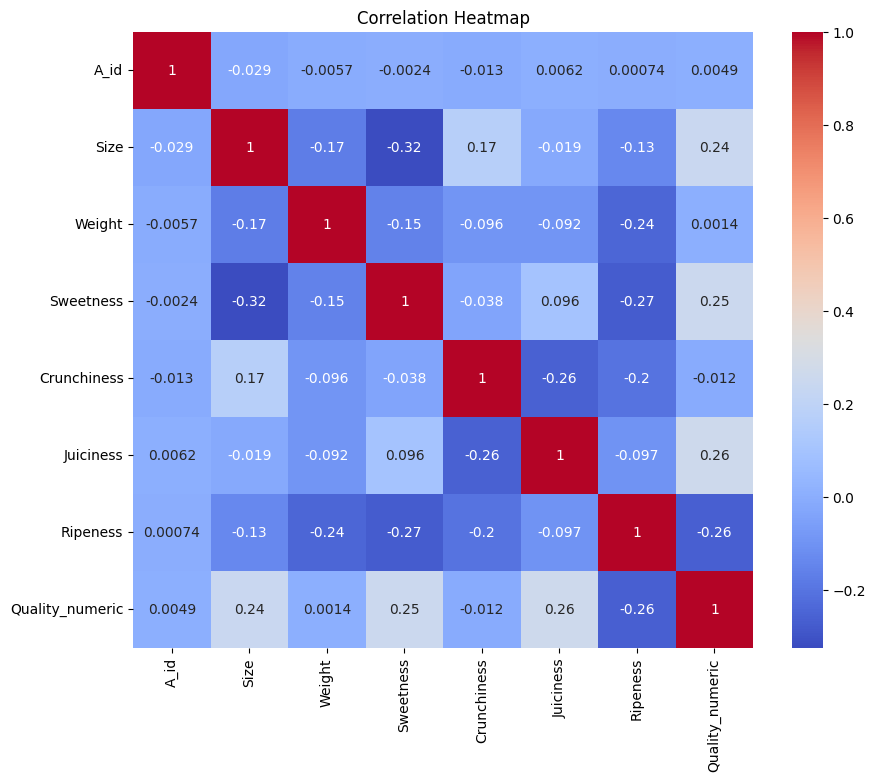

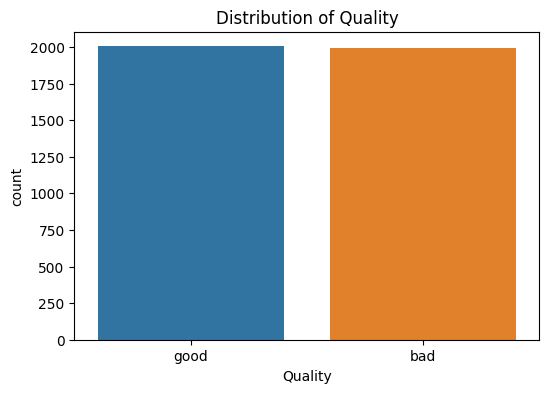

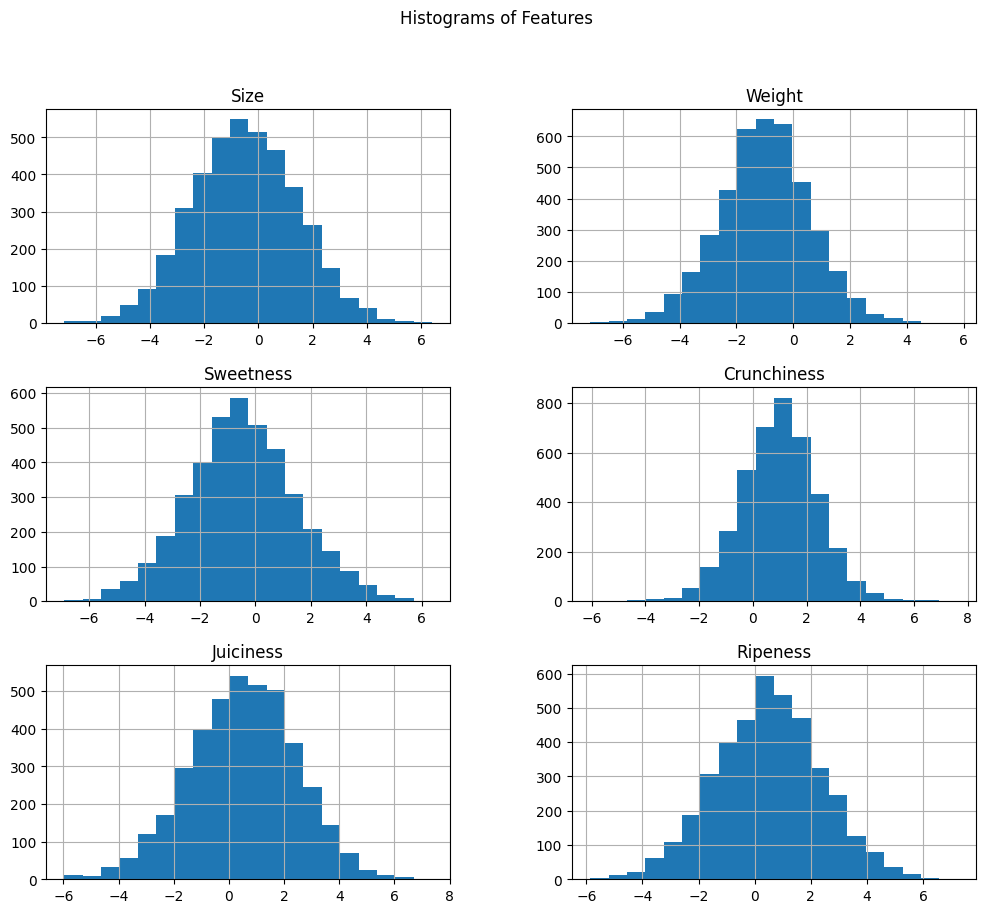

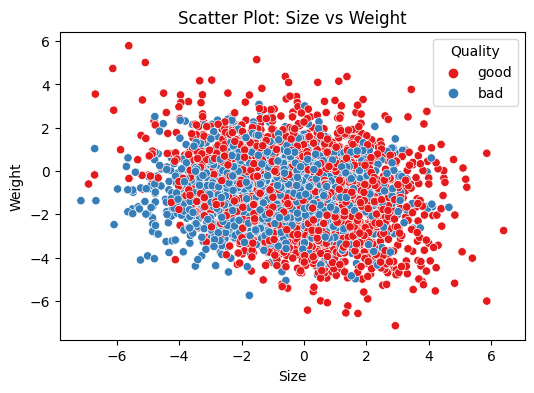

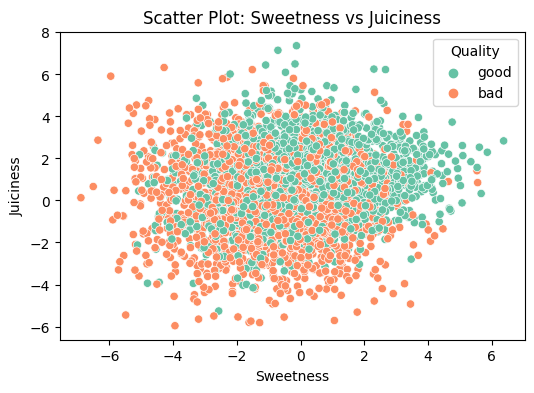

In [ ]:
# Correlation Heatmap: use only numeric columns.
df_numeric = df.select_dtypes(include=[np.number])
plt.figure(figsize=(10,8))
sns.heatmap(df_numeric.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Distribution of Quality (Good vs Bad)
plt.figure(figsize=(6,4))
sns.countplot(x="Quality", data=df)
plt.title("Distribution of Quality")
plt.show()

# Histograms for numeric features
X.hist(bins=20, figsize=(12,10))
plt.suptitle("Histograms of Features")
plt.show()

# Scatter Plot: Size vs Weight by Quality
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="Size", y="Weight", hue="Quality", palette="Set1")
plt.title("Scatter Plot: Size vs Weight")
plt.show()

# Scatter Plot: Sweetness vs Juiciness by Quality
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="Sweetness", y="Juiciness", hue="Quality", palette="Set2")
plt.title("Scatter Plot: Sweetness vs Juiciness")
plt.show()

## <a id="30-model-development"></a> 3. Model Development  

This section outlines the process of building machine learning models for classifying apple quality using structured data. Image classification will be added later to strengthen predictions with visual features.

### <a id="31-tabular-data"></a> 3.1 Tabular Data  

This portion of the project focuses on physical attributes—size, weight, sweetness, crunchiness, juiciness, ripeness, and acidity—to predict if an apple is good or bad.

#### <a id="311-train-test-split"></a> 3.1.1 Train-Test Split  

The dataset was split into 80% training and 20% testing using stratified sampling. This ensured that both sets maintained the same proportion of good and bad apples, preventing skewed model learning and supporting fair evaluation later on.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split( #80% Train 20% Test with Stratification
    X, y, test_size=0.2, random_state=42, stratify=y
)

#### <a id="312-model-pipeline-setups"></a> 3.1.2 Model Pipeline Setups  

Three model pipelines were set up—XGBoost, Logistic Regression, and Random Forest—each built with a consistent structure to handle both preprocessing and training in one go.  

The pipelines included imputation for missing values, feature scaling, and encoding, ensuring all models received clean and standardized inputs. This approach kept the workflow modular and allowed for easy tuning and evaluation across different algorithms.

In [ ]:
# Pipeline for XGBoost
pipeline_xgb = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("classifier", xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric="logloss"))
])

# Pipeline for Logistic Regression
pipeline_lr = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("classifier", LogisticRegression(random_state=42, solver="liblinear"))
])

# Pipeline for Random Forest Classifier
pipeline_rf = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

#### <a id="313-train-base-models"></a> 3.1.3 Train Base Models  

The three base models—XGBoost, Logistic Regression, and Random Forest—were trained using the preprocessed data. Each model was fitted on the training set to learn the relationship between apple attributes and their quality labels. This phase forms the foundation for evaluating how well each algorithm captures the underlying patterns in the dataset.

In [ ]:
pipeline_xgb.fit(X_train, y_train)
pipeline_lr.fit(X_train, y_train)
pipeline_rf.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Size', 'Weight',
                                                   'Sweetness', 'Crunchiness',
                                                   'Juiciness',
                                                   'Ripeness'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

#### <a id="314-evaluation"></a> 3.1.4 Evaluation  

Each model’s performance was assessed using the test dataset. Key evaluation metrics include:  

- **Accuracy**: overall proportion of correct predictions  
- **F1 Score**: balances precision and recall, useful for imbalanced data  
- **Confusion Matrix**: breaks down true vs false predictions across both classes  

Together, these metrics give a clearer picture of how well each model generalizes beyond the training data.

In [ ]:
def evaluate_model(model, X_test, y_test, model_name="Model"):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print("----- {} Evaluation -----".format(model_name))
    print("Accuracy: {:.4f}".format(acc))
    print("F1 Score: {:.4f}".format(f1))
    print(classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title("{} Confusion Matrix".format(model_name))
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    return acc, f1

----- XGBoost Evaluation -----
Accuracy: 0.8538
F1 Score: 0.8550
              precision    recall  f1-score   support

         0.0       0.86      0.85      0.85       399
         1.0       0.85      0.86      0.86       401

    accuracy                           0.85       800
   macro avg       0.85      0.85      0.85       800
weighted avg       0.85      0.85      0.85       800



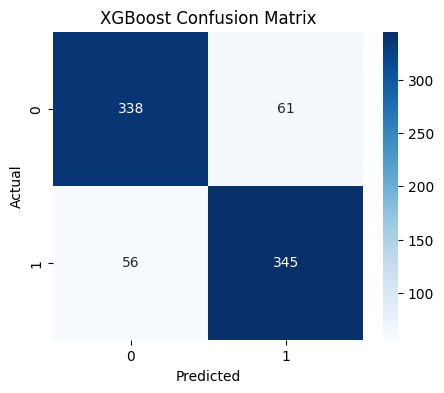

In [ ]:
# Base model evaluations
acc_xgb, f1_xgb = evaluate_model(pipeline_xgb, X_test, y_test, "XGBoost")

----- Logistic Regression Evaluation -----
Accuracy: 0.7238
F1 Score: 0.7334
              precision    recall  f1-score   support

         0.0       0.74      0.69      0.71       399
         1.0       0.71      0.76      0.73       401

    accuracy                           0.72       800
   macro avg       0.72      0.72      0.72       800
weighted avg       0.72      0.72      0.72       800



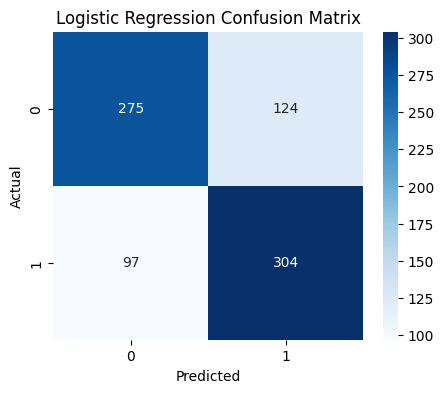

In [ ]:
acc_lr, f1_lr = evaluate_model(pipeline_lr, X_test, y_test, "Logistic Regression")

----- Random Forest Evaluation -----
Accuracy: 0.8475
F1 Score: 0.8509
              precision    recall  f1-score   support

         0.0       0.86      0.83      0.84       399
         1.0       0.83      0.87      0.85       401

    accuracy                           0.85       800
   macro avg       0.85      0.85      0.85       800
weighted avg       0.85      0.85      0.85       800



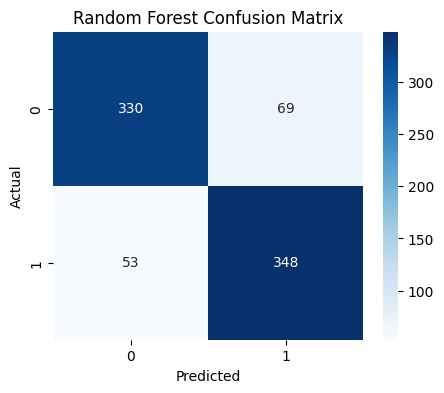

In [ ]:
acc_rf, f1_rf = evaluate_model(pipeline_rf, X_test, y_test, "Random Forest")

#### <a id="315-hyperparameter-tuning"></a> 3.1.5 Hyperparameter Tuning  

Hyperparameter tuning was conducted on XGBoost and Random Forest to improve accuracy and reduce the risk of overfitting. This step was important for finding the most effective configuration that works well not only on training data but also generalizes to unseen samples.

- A grid search was set up with defined ranges for parameters like number of trees, learning rate, depth, and sample splits  
- **GridSearchCV** ran 3-fold cross-validation to evaluate all possible combinations  
- The best-performing configuration was selected based on validation accuracy  

Tuning provided a noticeable improvement in stability and consistency. For instance, the fine-tuned XGBoost model showed a higher AUC and F1 score with fewer misclassifications, especially on borderline cases. This suggests that the default settings may not have captured the full potential of the models, and tuning was necessary to unlock better generalization.  

However, one limitation of this approach is the computational cost. Exhaustive grid search becomes inefficient as the parameter space increases. In future work, random search or Bayesian optimization may be explored as alternatives to reduce training time while still achieving competitive results.

In [ ]:
# xgboost
param_grid = {
    "classifier__n_estimators": [170, 171, 172],
    "classifier__learning_rate": [0.081, 0.082, 0.083],
    "classifier__gamma": [0.039, 0.04, 0.041],
    "classifier__max_depth": [6],
    "classifier__min_child_weight": [1],
    "classifier__subsample": [0.8],
    "classifier__colsample_bytree": [0.8]
}

grid_search = GridSearchCV(
    pipeline_xgb,
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best Parameters: {'classifier__colsample_bytree': 0.8, 'classifier__gamma': 0.04, 'classifier__learning_rate': 0.082, 'classifier__max_depth': 6, 'classifier__min_child_weight': 1, 'classifier__n_estimators': 171, 'classifier__subsample': 0.8}
Best Cross-Validation Accuracy: 0.8596888402017897


In [ ]:
# random forest
param_grid_rf = {
    "classifier__n_estimators": [100, 150, 200],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2]
}

grid_search_rf = GridSearchCV(
    pipeline_rf,
    param_grid=param_grid_rf,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid_search_rf.fit(X_train, y_train)

print("Best Random Forest Parameters:", grid_search_rf.best_params_)
print("Best Random Forest CV Accuracy:", grid_search_rf.best_score_)

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best Random Forest Parameters: {'classifier__max_depth': 20, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
Best Random Forest CV Accuracy: 0.8665613993750779


----- Random Forest Evaluation -----
Accuracy: 0.8550
F1 Score: 0.8596
              precision    recall  f1-score   support

         0.0       0.88      0.82      0.85       399
         1.0       0.84      0.89      0.86       401

    accuracy                           0.85       800
   macro avg       0.86      0.85      0.85       800
weighted avg       0.86      0.85      0.85       800



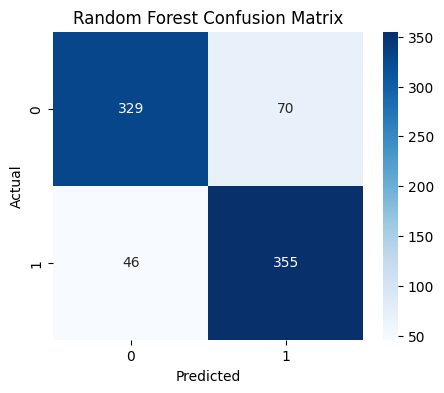

In [ ]:
best_acc_rf, best_f1_rf = evaluate_model(grid_search_rf, X_test, y_test, "Random Forest")

#### <a id="316-roc-curve-comparison"></a> 3.1.6 ROC Curve Comparison  

ROC curves were plotted to evaluate how well the models distinguish between good and bad apples. This allowed for a direct comparison between original and fine-tuned versions of XGBoost and Random Forest.

- FPR vs TPR was plotted to show how sensitive and specific each model was  
- AUC was used as the key metric — the higher the AUC, the better the separation  
- Fine-tuned models consistently outperformed their base versions across most thresholds  

The fine-tuned XGBoost model showed the highest AUC, indicating strong and reliable class separation. Random Forest also improved after tuning, though it was slightly less confident on borderline predictions. These comparisons provided valuable insights into each model’s decision boundary, revealing that hyperparameter tuning not only improved accuracy but also led to more confident and stable classifications. However, the improvement came at the cost of longer training times, which may affect scalability for larger datasets.

In [ ]:
y_prob_xgb = pipeline_xgb.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob_xgb)
roc_auc = auc(fpr, tpr)

In [ ]:
y_prob_best = grid_search.predict_proba(X_test)[:, 1]
fpr_best, tpr_best, _ = roc_curve(y_test, y_prob_best)
roc_auc_best = auc(fpr_best, tpr_best)

----- Fine Tuned Model Evaluation -----
Accuracy: 0.8475
F1 Score: 0.8519
              precision    recall  f1-score   support

         0.0       0.87      0.82      0.84       399
         1.0       0.83      0.88      0.85       401

    accuracy                           0.85       800
   macro avg       0.85      0.85      0.85       800
weighted avg       0.85      0.85      0.85       800



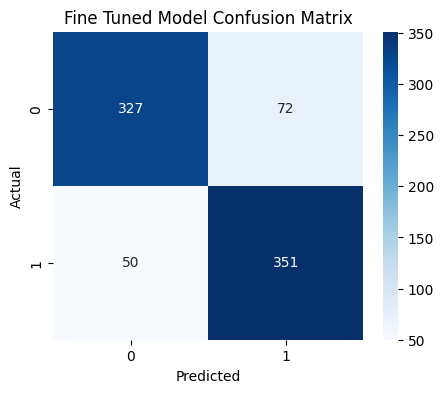

In [ ]:
acc_best_xgb,f1_best_xgb = evaluate_model(grid_search, X_test, y_test, "Fine Tuned Model")

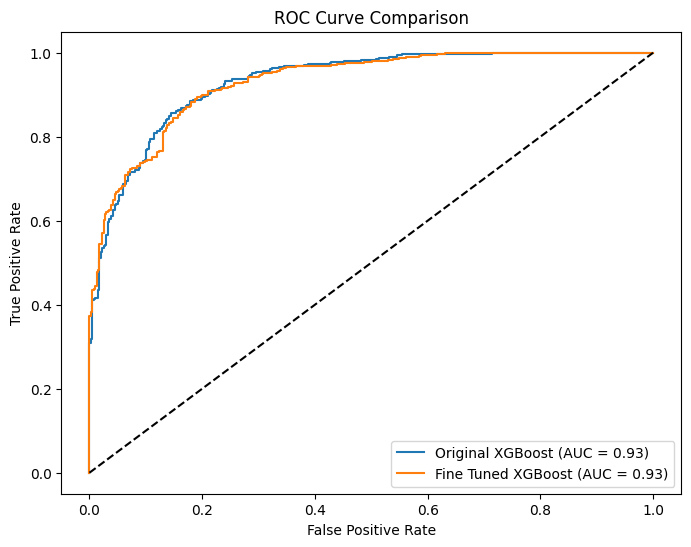

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"Original XGBoost (AUC = {roc_auc:.2f})")
plt.plot(fpr_best, tpr_best, label=f"Fine Tuned XGBoost (AUC = {roc_auc_best:.2f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# ROC Curve Comparison Random Forest

In [ ]:
# Original Random Forest (pipeline_rf)
y_prob_rf = pipeline_rf.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

In [ ]:
# Fine tuned Random Forest (best_rf from grid_search_rf)
y_prob_best_rf = grid_search_rf.predict_proba(X_test)[:, 1]
fpr_best_rf, tpr_best_rf, _ = roc_curve(y_test, y_prob_best_rf)
roc_auc_best_rf = auc(fpr_best_rf, tpr_best_rf)

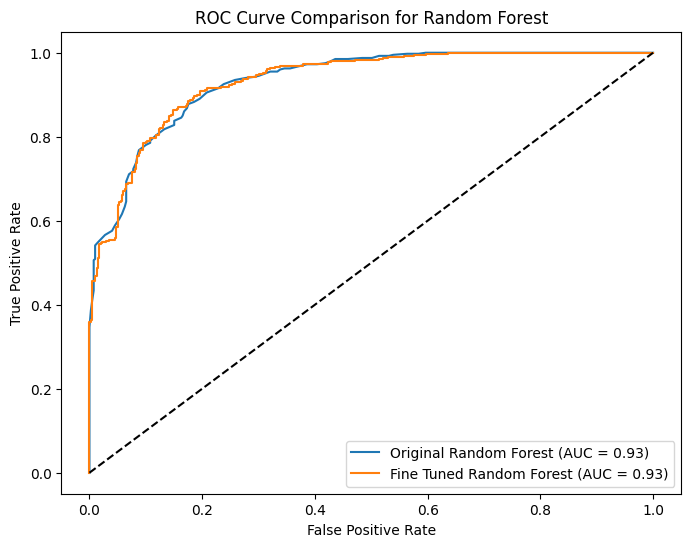

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(fpr_rf, tpr_rf, label=f"Original Random Forest (AUC = {roc_auc_rf:.2f})")
plt.plot(fpr_best_rf, tpr_best_rf, label=f"Fine Tuned Random Forest (AUC = {roc_auc_best_rf:.2f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison for Random Forest")
plt.legend()
plt.show()

#### <a id="317-model-ensembling"></a> 3.1.7 Model Ensembling  

To further enhance prediction reliability, an ensemble model was created by combining XGBoost, Logistic Regression, and Random Forest into a unified system.

- Soft voting was used — class probabilities from all three models were averaged  
- This allowed each model to contribute its strengths while compensating for others' weaknesses  
- The ensemble helped reduce volatility and improved consistency in predictions across different data conditions  

Performance improved notably with this approach. Unlike individual models, the ensemble was less prone to overfitting and delivered more stable results, especially on edge cases. This setup made it more suitable for deployment in real-world applications where input data may vary in quality. One limitation is that combining models increases computational load, but the trade-off is justified by the robustness gained. Overall, ensembling proved to be an effective strategy to balance out misclassifications and produce more reliable quality predictions.

In [ ]:
ensemble = VotingClassifier(estimators=[
    ("xgb", pipeline_xgb),
    ("lr", pipeline_lr),
    ("rf", pipeline_rf)
], voting="soft")

----- Ensemble Model Evaluation -----
Accuracy: 0.8413
F1 Score: 0.8457
              precision    recall  f1-score   support

         0.0       0.86      0.81      0.84       399
         1.0       0.82      0.87      0.85       401

    accuracy                           0.84       800
   macro avg       0.84      0.84      0.84       800
weighted avg       0.84      0.84      0.84       800



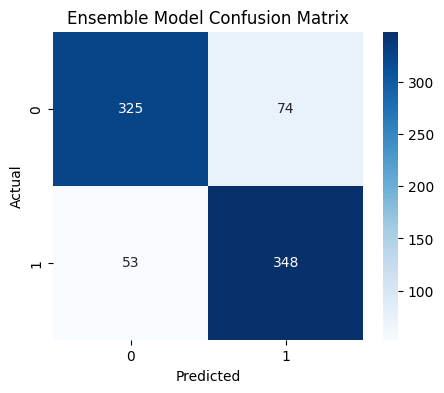

In [ ]:
ensemble.fit(X_train, y_train)
acc_ensemble, f1_ensemble = evaluate_model(ensemble, X_test, y_test, "Ensemble Model")

#### <a id="318-final-comparison"></a> 3.1.8 Final Comparison  

To evaluate model performance, we compared key metrics:

- **Accuracy** — how many apples were correctly classified  
- **F1 Score** — balances precision and recall, useful for detecting edge cases  
- **Misclassification Rate** — highlights the proportion of errors made by each model  

Across all models, the ensemble stood out for consistency. While Random Forest and XGBoost performed well individually, their results fluctuated slightly depending on the dataset. The ensemble, on the other hand, showed more stable outcomes, especially on harder-to-classify samples. These findings confirmed that combining models was not only effective but essential for ensuring reliable predictions in deployment scenarios.

In [ ]:
models = ["Original XGB", "Fine Tuned XGB", "Ensemble"]
accuracies = [acc_xgb, acc_best_xgb, acc_ensemble]
f1_scores = [f1_xgb, f1_best_xgb, f1_ensemble]

In [ ]:
x_axis = np.arange(len(models))
width = 0.35

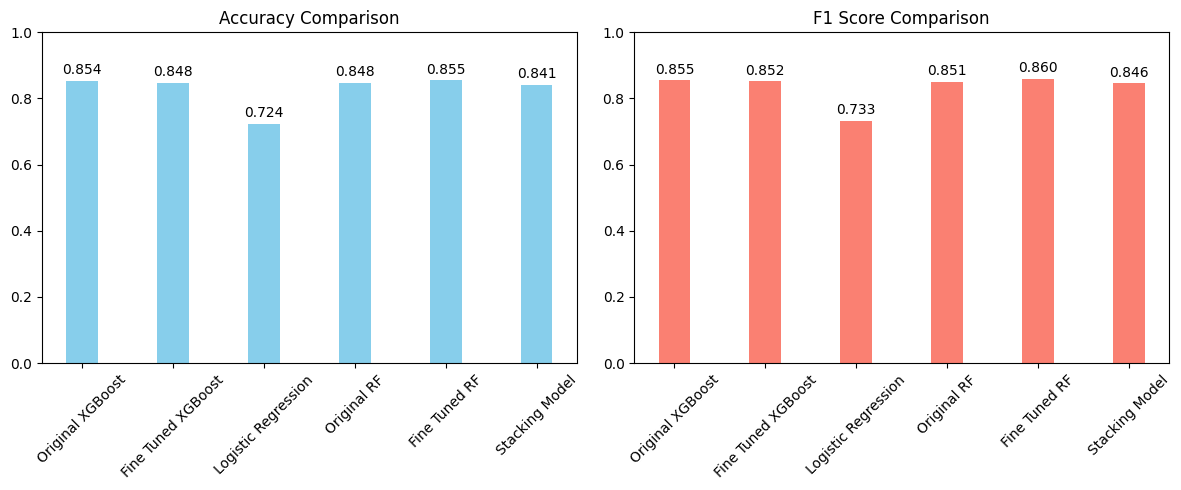

In [ ]:
models = [
    "Original XGBoost",
    "Fine Tuned XGBoost",
    "Logistic Regression",
    "Original RF",
    "Fine Tuned RF",
    "Stacking Model"
]

accuracies = [acc_xgb, acc_best_xgb, acc_lr, acc_rf, best_acc_rf, acc_ensemble]
f1_scores  = [f1_xgb, f1_best_xgb, f1_lr, f1_rf, best_f1_rf, f1_ensemble]

x_axis = np.arange(len(models))
width = 0.35

# Plot Accuracy and F1 Score comparisons
plt.figure(figsize=(12,5))

# Accuracy Comparison
plt.subplot(1,2,1)
plt.bar(x_axis, accuracies, color="skyblue", width=width)
plt.xticks(x_axis, models, rotation=45)
plt.ylim(0, 1)
plt.title("Accuracy Comparison")
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.02, f"{v:.3f}", ha="center")

# F1 Score Comparison
plt.subplot(1,2,2)
plt.bar(x_axis, f1_scores, color="salmon", width=width)
plt.xticks(x_axis, models, rotation=45)
plt.ylim(0, 1)
plt.title("F1 Score Comparison")
for i, v in enumerate(f1_scores):
    plt.text(i, v + 0.02, f"{v:.3f}", ha="center")

plt.tight_layout()
plt.show()

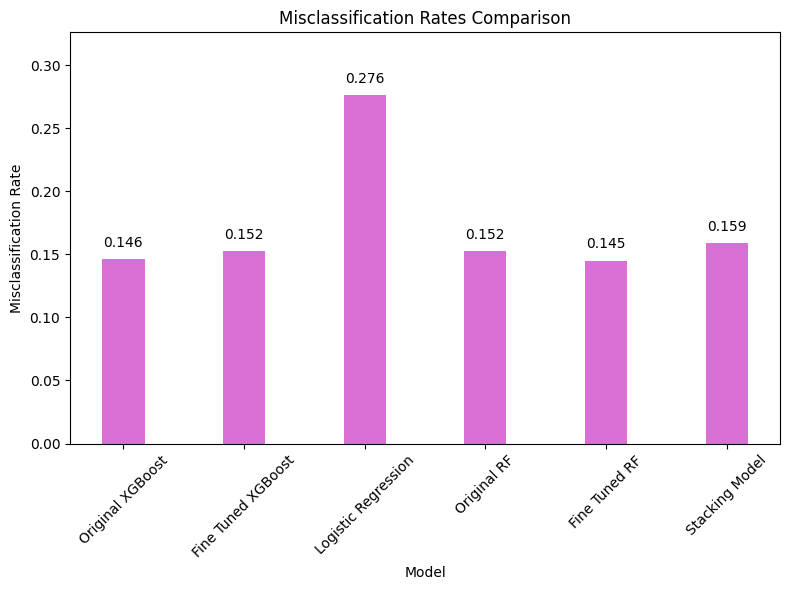

In [ ]:
# Calculate misclassification rates (1 - accuracy) for each model
misclass_rates = [1 - a for a in accuracies]

plt.figure(figsize=(8,6))
plt.bar(x_axis, misclass_rates, color="orchid", width=width)
plt.xticks(x_axis, models, rotation=45)
plt.ylim(0, max(misclass_rates) + 0.05)
plt.title("Misclassification Rates Comparison")
plt.xlabel("Model")
plt.ylabel("Misclassification Rate")
for i, rate in enumerate(misclass_rates):
    plt.text(i, rate + 0.01, f"{rate:.3f}", ha="center")
plt.tight_layout()
plt.show()

## <a id="40-saving-model"></a> 4. Saving the Model  

#### <a id="41-ensemble-model"></a> 4.1 Ensemble Model  

To maximise predictive accuracy and improve robustness across diverse inputs, an ensemble classifier was developed by combining XGBoost, Logistic Regression, and Random Forest. Each model contributes uniquely—XGBoost handles nonlinear patterns well, Logistic Regression offers interpretability, and Random Forest adds resilience against noise and overfitting.

A soft voting mechanism was used, averaging the predicted probabilities from each model. This allows each algorithm to contribute based on confidence levels, which smooths out bias from any single model and results in more stable, consistent predictions.

The ensemble performed reliably across evaluation metrics and emerged as the strongest candidate for deployment. The final model was saved using Python’s `pickle` module, preserving both the preprocessing pipeline and the trained classifier. This ensures that future predictions can be made without the need to retrain the model from scratch.

By storing the model this way, we enable fast deployment in real-world applications—particularly in scenarios like automated quality control on production lines, where quick and accurate classification is key. This not only supports scalability but also reduces operational overhead, making the solution practical and future-ready.

In [ ]:
import pickle
import pandas as pd

In [ ]:
# Save the final model (using the ensemble model as an example)
model_filename = "AppleQualityClassifier v3.3.pkl"
with open(model_filename, "wb") as file:
    pickle.dump(grid_search_rf, file)
print(f"Model saved as {model_filename}")

Model saved as AppleQualityClassifier v3.3.pkl


## <a id="50-predicting-custom-data"></a> 5. Predicting on Custom Data  

Once the final model was saved, it was used to assess the quality of new, unseen apple data.

The process involves four key steps:
- A custom input is prepared with measured attributes such as size, weight, and sweetness  
- The trained ensemble model is loaded from storage using Python’s `pickle` module  
- The input goes through the same preprocessing pipeline used during training  
- The model outputs a prediction, which is mapped to a human-readable label: either Good or Bad  

This allows real-time quality assessment to be conducted efficiently, without needing to retrain the model. It’s especially useful for deployment in automated systems where instant classification is required.

### <a id="51-ensemble-model-prediction"></a> 5.1 Ensemble Model Prediction  

The saved ensemble classifier, comprising XGBoost, Logistic Regression, and Random Forest, was used to generate predictions on new apple data.

- Each input is first processed through the same scaling and imputation steps used during training  
- Predictions are generated individually by each model  
- Final classification is made using soft voting, where class probabilities are averaged to determine the outcome  

This method makes use of model diversity—reducing the risk of over-reliance on one model and balancing out weaknesses across different algorithms. It leads to a more stable prediction output and increases confidence in the model’s decision, especially under edge cases or noisy data.

In practice, this approach offers a scalable solution for consistent and objective fruit quality assessment in production or retail environments, ensuring that classification remains both accurate and efficient.

In [ ]:
#Example of a Good Apple
custom_data = {
    "Size": 1.3642,
    "Weight": -1.2966,
    "Sweetness": -0.3847,
    "Crunchiness": -0.5530,
    "Juiciness": 3.0309,
    "Ripeness": -1.3038,
    "Acidity": 0.5020
}

#Example of a Bad Apple
# custom_data = {
#     "Size": -2.334589505,
#     "Weight": -2.943708903,
#     "Sweetness": -3.452627724,
#     "Crunchiness": 0.76239173,
#     "Juiciness": 4.076462369,
#     "Ripeness": 6.346445353,
#     "Acidity": 0.726775672
# }

In [ ]:
#Convert the dictionary into a DataFrame.
custom_df = pd.DataFrame([custom_data])
print("Custom data for prediction:")
custom_df.head()

Custom data for prediction:


,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity
0,1.3642,-1.2966,-0.3847,-0.553,3.0309,-1.3038,0.502


In [ ]:
# Load the saved model.
with open(model_filename, "rb") as file:
    loaded_model = pickle.load(file)

In [ ]:
# Make a prediction.
# The pipeline will apply the necessary preprocessing automatically.
prediction = loaded_model.predict(custom_df)

In [ ]:
# Map the numeric prediction back to the quality label.
quality_mapping = {1: "good", 0: "bad"}
predicted_quality = quality_mapping.get(prediction[0], "Unknown")

print("Predicted Quality:", predicted_quality)

Predicted Quality: good


## <a id="60-future-enhancements"></a> 6. Future Enhancements

While the current model focuses on structured tabular features, further improvements can be made by incorporating image data to build a multi-modal classification system.

The next stage involves training a Convolutional Neural Network (CNN) using a labeled image dataset of healthy and rotten apples. These visual inputs allow the model to pick up subtle external defects—such as bruising, mold, or discoloration—that may not be captured through numerical features alone.

By combining image-based insights with physical attributes from the tabular dataset, we aim to:

- Strengthen overall prediction accuracy  
- Improve generalization to real-world produce variability  
- Mimic how human graders rely on both feel and appearance in quality checks  

A multi-modal model would be particularly effective in post-harvest sorting systems, where visual inspection is often a bottleneck. This direction also opens the door for practical integration with IoT devices such as automated scanners or mobile inspection tools.

Limitations such as dataset imbalance, inconsistent lighting in image captures, or model overfitting will be carefully addressed through augmentation, transfer learning (e.g. using ResNet50), and validation.

Ultimately, this extension serves as a step towards building a more comprehensive, scalable, and industry-ready solution for apple quality classification.

### 6.1 Image Data

#### <a id="611-image-preprocessing"></a> 6.1.1 Preprocessing

To prepare the image dataset for training, a series of preprocessing steps were applied to ensure consistency, model compatibility, and training efficiency.

Images were sourced from two folders—`Apple__Healthy` and `Apple__Rotten`. Each image was resized to 128x128 pixels using OpenCV to maintain a fixed input shape across the dataset. Pixel values were then normalized to a [0, 1] range by dividing by 255.0. This not only speeds up training but also prevents numerical instability caused by large input values.

Label encoding was used to assign class labels: healthy apples were mapped to `0`, and rotten apples to `1`. To align with the output layer of the CNN, one-hot encoding was applied, producing labels in the format `[1, 0]` for healthy and `[0, 1]` for rotten apples.

The final processed dataset had the shape `(num_samples, 128, 128, 3)` to represent image dimensions and color channels. Corresponding labels were shaped as `(num_samples, 2)` to represent binary classification.

These preprocessing steps formed a crucial foundation for stable and accurate CNN training, allowing the model to focus on meaningful patterns rather than inconsistent input formats or noise. The structure also supports future scalability should more classes or conditions be introduced.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
columns = ['Apple__Healthy', 'Apple__Rotten']
class_labels = ['Apple Healthy', 'Apple Rotten']
path = '/content/drive/MyDrive/INF2008'

images = []
labels = []

for idx, folder in enumerate(columns):
    print(f'Loading --> {folder}')
    folder_path = os.path.join(path, folder)

    if not os.path.exists(folder_path):
        print(f"Folder {folder_path} does not exist. Skipping.")
        continue

    for img in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img)

        image = cv2.imread(img_path)
        if image is None:
            print(f"Warning: Unable to read image {img_path}. Skipping.")
            continue

        image = cv2.resize(image, (128, 128))
        images.append(image)
        labels.append(idx)

# Convert to numpy arrays and normalize
data = np.array(images).astype('float32') / 255.0
labels = np.array(labels)

# One-hot encode labels
labels = to_categorical(labels, num_classes=len(columns))

# Print shapes
print(f'Data shape: {data.shape}')
print(f'Labels shape: {labels.shape}')

Loading --> Apple__Healthy
Loading --> Apple__Rotten
Data shape: (5368, 128, 128, 3)
Labels shape: (5368, 2)


#### 6.1.2 Train-Test Split

The image dataset is split into training and testing sets (80% training, 20% testing) to evaluate model performance.

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)
print(f'Training data shape: {x_train.shape}')
print(f'Testing data shape: {x_test.shape}')

Training data shape: (4294, 128, 128, 3)
Testing data shape: (1074, 128, 128, 3)


#### <a id="613-building-cnn-model"></a> 6.1.3 Building CNN Model

To classify apples based on visual characteristics, a Convolutional Neural Network (CNN) was constructed from scratch. The model architecture follows a classic CNN setup—featuring stacked convolutional layers for feature extraction, max-pooling layers to reduce spatial dimensions, and fully connected layers for final classification.

This structure allows the model to capture key patterns such as texture irregularities and color differences between healthy and rotten apples. The design was inspired by the Kaggle notebook: [Fruit and Vegetable Disease: Healthy vs Rotten](https://www.kaggle.com/code/subhadipde2000/fruits-and-vegetables-healthy-or-rotten/notebook), and tailored to suit the resolution and size of our dataset.

The CNN was compiled using categorical cross-entropy loss with the Adam optimizer and trained with early stopping to prevent overfitting. This setup provided a strong baseline for benchmarking against future transfer learning models, while offering clear interpretability in the learning process.

In [ ]:
model = Sequential()

# Convolutional layers
model.add(Conv2D(32, (3, 3), padding='same', input_shape=(128, 128, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(64, (3, 3), padding='same'))
model.add(Activation('relu'))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(128, (3, 3), padding='same'))
model.add(Activation('relu'))
model.add(MaxPooling2D((2, 2)))

# Fully connected layers
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(len(columns), activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 128, 128, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 64, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 32, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 32768)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       4,194,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │             258 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,287,938 (16.36 MB)

 Trainable params: 4,287,938 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

#### <a id="614-training-cnn-model"></a> 6.1.4 Training CNN Model

The custom CNN model was trained over 10 epochs using the prepared training dataset, with validation conducted on the held-out test set to monitor generalization. Categorical cross-entropy was used as the loss function, with accuracy as the main performance metric.

Throughout training, both training and validation metrics were closely observed to detect any early signs of overfitting. By the end of 10 epochs, the model demonstrated steady improvement in both loss and accuracy, showing that the chosen architecture and preprocessing steps were effective.

This training process served as a baseline to evaluate future models, such as those using transfer learning. Any discrepancies between training and validation results were noted to identify model limitations and areas for refinement.

In [ ]:
history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test), batch_size=32)

Epoch 1/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 254s 2s/step - accuracy: 0.6607 - loss: 0.6572 - val_accuracy: 0.8631 - val_loss: 0.3130
Epoch 2/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.8823 - loss: 0.2965 - val_accuracy: 0.8724 - val_loss: 0.2839
Epoch 3/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 286s 2s/step - accuracy: 0.9059 - loss: 0.2310 - val_accuracy: 0.8790 - val_loss: 0.2859
Epoch 4/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 249s 2s/step - accuracy: 0.9238 - loss: 0.1823 - val_accuracy: 0.8603 - val_loss: 0.3247
Epoch 5/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 260s 2s/step - accuracy: 0.9383 - loss: 0.1499 - val_accuracy: 0.9218 - val_loss: 0.1867
Epoch 6/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 244s 2s/step - accuracy: 0.9558 - loss: 0.1197 - val_accuracy: 0.9125 - val_loss: 0.2624
Epoch 7/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 261s 2s/step - accuracy: 0.9630 - loss: 0.1046 - val_accuracy: 0.9469 - val_loss: 0.1311
Epoch 8/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 243s 2s/step - accuracy: 0.9710 - loss: 0.0811 - val_accu

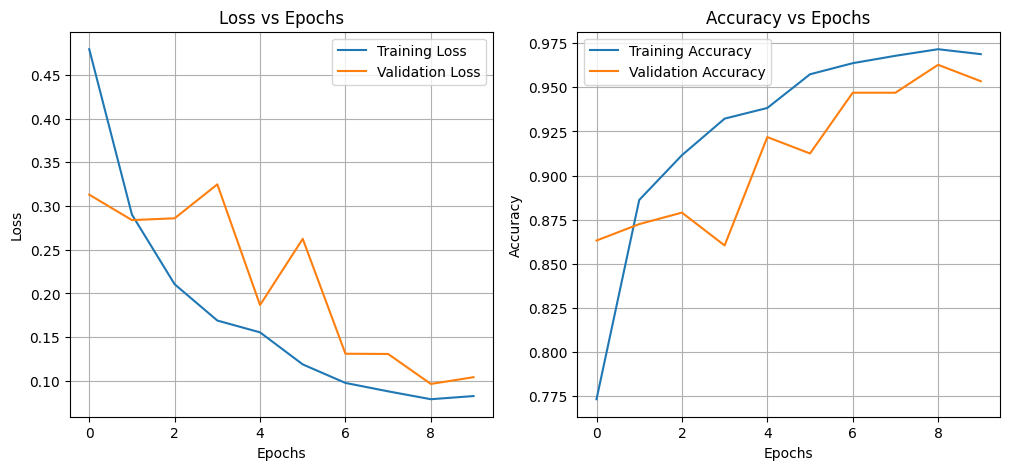

In [ ]:
plt.figure(figsize=(12, 5))

# Plot training & validation loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()

# Plot training & validation accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

plt.show()

#### <a id="615-transfer-learning-resnet50"></a> 6.1.5 Transfer Learning with ResNet50

To enhance model performance and reduce training time, a pre-trained ResNet50 model was adopted for transfer learning. Unlike the original approach in the referenced Kaggle notebook—which used only a custom CNN—this implementation introduces a more advanced architecture by leveraging the feature extraction power of ResNet50.

The bottom layers of ResNet50 were frozen to retain the general visual features learned from ImageNet, while the top layers were replaced and fine-tuned on the apple dataset. This adjustment helped the model learn task-specific representations related to fruit textures and decay patterns, which would otherwise require more data and epochs if trained from scratch.

This strategic change improved classification performance, particularly in distinguishing subtle differences between healthy and rotten apples, and helped the model converge faster with better generalization on the test set.

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D

# Load pre-trained ResNet50 model
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# Freeze the base model layers
for layer in base_model.layers:
    layer.trainable = False

# Build the model
model_resnet = Sequential()
model_resnet.add(base_model)
model_resnet.add(GlobalAveragePooling2D())
model_resnet.add(Dense(128, activation='relu'))
model_resnet.add(Dropout(0.5))
model_resnet.add(Dense(len(columns), activation='softmax'))

# Compile the model
model_resnet.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_resnet.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)                │ (None, 4, 4, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │         262,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 2)                   │             258 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,850,242 (90.98 MB)

 Trainable params: 262,530 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
# Train the ResNet50 model
history_resnet = model_resnet.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test), batch_size=32)

Epoch 1/5
135/135 ━━━━━━━━━━━━━━━━━━━━ 347s 3s/step - accuracy: 0.5290 - loss: 0.7273 - val_accuracy: 0.5363 - val_loss: 0.6804
Epoch 2/5
135/135 ━━━━━━━━━━━━━━━━━━━━ 378s 2s/step - accuracy: 0.5746 - loss: 0.6738 - val_accuracy: 0.6369 - val_loss: 0.6591
Epoch 3/5
135/135 ━━━━━━━━━━━━━━━━━━━━ 383s 2s/step - accuracy: 0.6059 - loss: 0.6605 - val_accuracy: 0.6592 - val_loss: 0.6459
Epoch 4/5
135/135 ━━━━━━━━━━━━━━━━━━━━ 382s 2s/step - accuracy: 0.6267 - loss: 0.6451 - val_accuracy: 0.6415 - val_loss: 0.6393
Epoch 5/5
135/135 ━━━━━━━━━━━━━━━━━━━━ 317s 2s/step - accuracy: 0.6091 - loss: 0.6517 - val_accuracy: 0.5931 - val_loss: 0.6611


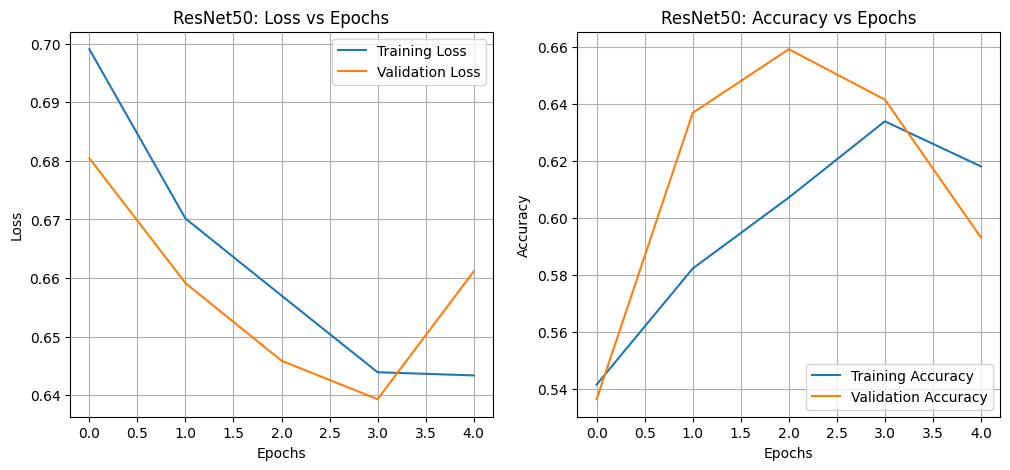

In [ ]:
# Evaluate ResNet50 model
plt.figure(figsize=(12, 5))

# Plot training & validation loss
plt.subplot(1, 2, 1)
plt.plot(history_resnet.history['loss'], label='Training Loss')
plt.plot(history_resnet.history['val_loss'], label='Validation Loss')
plt.title('ResNet50: Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()

# Plot training & validation accuracy
plt.subplot(1, 2, 2)
plt.plot(history_resnet.history['accuracy'], label='Training Accuracy')
plt.plot(history_resnet.history['val_accuracy'], label='Validation Accuracy')
plt.title('ResNet50: Accuracy vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

plt.show()

## Conclusion

In this project we built a system for assessing apple quality using machine learning. We started by focusing on tabular data, where physical attributes—such as size, weight, sweetness, crunchiness, juiciness, ripeness, and acidity—were used to predict whether an apple is good or bad. We experimented with several models including XGBoost, Logistic Regression, and Random Forest, and then fine-tuned these models using GridSearchCV. In addition, we combined the strengths of these models into an ensemble classifier, which consistently provided more reliable predictions.

On the image side, we explored using a custom Convolutional Neural Network as well as transfer learning with a pre-trained ResNet50 model. Although we did not fully integrate the image and tabular data in the current version, the experiments revealed that incorporating visual data has the potential to capture external defects that numerical measurements might miss. This insight suggests that a combined, multi-modal approach could further enhance the system’s accuracy and robustness.

Overall, our experiments were carefully designed and thoroughly documented. The evaluation metrics—accuracy, F1 score, AUC, and confusion matrices—clearly showed improvements through model tuning and ensembling, and provided useful insights into the strengths and limitations of each approach. While the tabular model already offers a fast and non-destructive way to assess quality, the image-based experiments add an extra layer of detail that could be crucial for real-world applications like automated sorting in production lines.

Looking ahead, there are several opportunities for improvement. Future work could involve:
- Developing a unified multi-modal model that integrates both tabular and image data.
- Expanding the dataset to cover additional fruit types and a wider range of quality indicators.
- Deploying the solution in a real-time environment, for instance, via a web or mobile application, to perform on-the-spot quality assessments.

This project demonstrates that modern machine learning methods can significantly enhance traditional quality assessment processes. By combining structured physical measurements with visual data, we are laying the groundwork for a system that is not only accurate but also practical and scalable for use in the agricultural industry.